# 3단계 — 파이프라인 추론 (탐지 + SARATR-X 분류)

## 이 노트북의 역할
ResNet18 버전(`single_resnet18.ipynb`)과 동일한 평가를 **분류기만 SARATR-X로 교체**해 수행.
ResNet18 결과와 직접 비교해 "분류기 업그레이드가 파이프라인 전체 성능에 주는 효과"를 측정한다.

## ResNet18 버전과의 차이 (이것만 다름)
| 항목 | ResNet18 버전 | 이 노트북 |
|---|---|---|
| 분류기 | resnet18 (torchvision) | **SARATR-X (HiViT-base + repo 코드)** |
| 분류 입력 | 크롭 128 그대로 | 크롭 128 → **Resize 224** (HiViT 규격) |
| 분류 추론 | FP32 | **AMP(FP16)** — ViT라 속도 이득 큼 |
| 탐지기/SAHI/conf/크롭 방식 | — | **전부 동일** (공정 비교) |

## 비교 기준 (ResNet18 파이프라인 결과)
- 파트 A 파이프라인 정확도: **79.01%** (분류기 단독 80.49%)
- 파트 B 장면: 탐지 recall 95.0% / E2E **70.0%** / 분류(탐지 성공분) 73.7%
- SARATR-X 단독 89.30% → 파이프라인 ~87~88%, 장면 E2E 상승 기대

## 사전 준비
- 드라이브: `checkpoints/yolo_detector.pt`, `checkpoints/saratrx_soc50_final.pth`, `soc50.tar`, `dom_scenes.tar`
- HF 약관 동의 불필요 (가중치는 드라이브에서 로드, repo 코드만 clone)
- 런타임 → A100 권장 (T4 가능, 파트 A가 ~20분으로 느려짐)

## 1. 환경 준비

- ultralytics + sahi: 탐지/타일링
- timm + repo clone: SARATR-X(HiViT) 모델 정의 코드

In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')

!pip -q install ultralytics sahi timm
!git clone -q https://github.com/waterdisappear/SARATR-X.git /content/SARATR-X

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "/", torch.cuda.get_device_name(0))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.3 MB/s eta 0:00:00
device: cuda / NVIDIA A100-SXM4-40GB


In [ ]:
# 2. 데이터 준비 (ResNet18 버전과 동일 — 이미 풀려있으면 건너뜀)
import os, glob

SETTING  = "SOC_50classes"
DATA_DIR = f"/content/{SETTING}"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

TEST_DIR = os.path.join(DATA_DIR, "test")

if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar

scene_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))
print(f"test 클래스 수: {len(os.listdir(TEST_DIR))} / DOM 장면: {len(scene_tifs)}장")

test 클래스 수: 50 / DOM 장면: 48장


## 3. 두 모델 로드

- **탐지기**: ResNet18 버전과 완전히 동일 (yolo_detector.pt, conf 0.5, image_size 256)
- **분류기**: SARATR-X — repo의 HiViT-base 백본 + 학습 노트북과 같은 래퍼 클래스로 재구성 후
  파인튜닝 가중치(`saratrx_soc50_final.pth`) 로드. **래퍼 구조가 학습 때와 완전히 같아야** state_dict 키가 맞음

In [ ]:
import sys
import torch.nn as nn
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ===== 1단계: 탐지기 (ResNet18 버전과 동일 설정) =====
DET_CONF = 0.5
det_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo_detector.pt",
    confidence_threshold=DET_CONF,
    device="cuda:0",
    image_size=256,
)

# ===== 2단계: 분류기 SARATR-X =====
sys.path.insert(0, "/content/SARATR-X/pre-training")   # repo 모델 코드 경로
from models import models_hivit

# 학습 노트북(classification/soc50/saratrx.ipynb)과 동일한 래퍼 — 구조가 다르면 가중치 로드 실패
class SARATRXClassifier(nn.Module):
    def __init__(self, backbone, num_classes, feat_dim=512):
        super().__init__()
        self.backbone = backbone
        self.norm = nn.LayerNorm(feat_dim)
        self.head = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.backbone.forward_features(x)   # (B, N, C) 패치 토큰
        if feats.dim() == 3:
            feats = feats.mean(dim=1)               # 평균 풀링 → (B, C)
        return self.head(self.norm(feats))

CLASS_NAMES = sorted(os.listdir(TEST_DIR))     # 학습 ImageFolder와 같은 알파벳순
NUM_CLASSES = len(CLASS_NAMES)

backbone = models_hivit.hivit_base()           # 빈 백본 생성 (사전학습 가중치 불필요 — 파인튜닝본을 로드하므로)
classifier = SARATRXClassifier(backbone, NUM_CLASSES, feat_dim=512)
classifier.load_state_dict(
    torch.load(f"{SAVE_DIR}/checkpoints/saratrx_soc50_final.pth", map_location=device))
classifier = classifier.to(device).eval()

print(f"탐지기(conf={DET_CONF}) + SARATR-X({NUM_CLASSES}클래스) 로드 완료")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


탐지기(conf=0.5) + SARATR-X(50클래스) 로드 완료


## 4. 공통 함수 — 고정 창 크롭 + 분류

ResNet18 버전과 같은 **박스 중심 고정 128×128 창 크롭** (스케일 보존 — 시행착오로 확립한 방식).
차이는 마지막에 **224로 리사이즈** (HiViT 입력 규격)와 **AMP 추론**뿐.

> 왜 128 창 → 224 리사이즈인가? 학습 때도 "128 슬라이스 → Resize 224"로 학습했으므로
> 추론도 같은 경로를 밟아야 분포가 일치한다.

In [ ]:
import numpy as np
from PIL import Image
import torchvision.transforms as T

Image.MAX_IMAGE_PIXELS = None

# 학습(classification/soc50/saratrx.ipynb)의 test_transform과 동일해야 함
cls_transform = T.Compose([
    T.Resize((224, 224)),                 # 128 크롭 → 224 (학습과 같은 경로)
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

def classify_box(pil_img, box, win=128):
    """박스 중심 고정 win×win 창 크롭 → SARATR-X로 차종 판별. 반환: (차종, 신뢰도)"""
    W, H = pil_img.size
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    left = min(max(cx - win / 2, 0), max(W - win, 0))   # 경계 클램핑
    top  = min(max(cy - win / 2, 0), max(H - win, 0))
    chip = pil_img.crop((left, top, left + win, top + win))

    x = cls_transform(chip).unsqueeze(0).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast():     # AMP — ViT 추론 속도 ~2배
        prob = torch.softmax(classifier(x).float(), dim=1)[0]
    idx = int(prob.argmax())
    return CLASS_NAMES[idx], float(prob[idx])

## 파트 A — 슬라이스 정량 평가

ResNet18 버전과 동일: test 17,603장, 탐지(conf 0.25 — 복잡 장면 슬라이스용 임계값) → 분류 → 채점.
ViT라 ResNet보다 느림 (A100 ~8분 / T4 ~20분). 급하면 `SAMPLE_N = 3000` 표본 평가.

In [ ]:
from ultralytics import YOLO
from tqdm import tqdm
import random

yolo_raw = YOLO(f"{SAVE_DIR}/checkpoints/yolo_detector.pt")

def run_pipeline_slice(img_path, det_conf=0.25):     # 슬라이스용 conf 0.25 (도메인별 임계값)
    pil_img = Image.open(img_path)
    rgb = np.array(pil_img.convert("RGB"))            # tif 1채널 → 3채널
    det = yolo_raw(rgb, conf=det_conf, verbose=False)[0]
    results = []
    for box in det.boxes:
        xyxy = box.xyxy[0].tolist()
        vtype, cconf = classify_box(pil_img, xyxy)
        results.append({"box": xyxy, "type": vtype,
                        "det_conf": float(box.conf[0]), "cls_conf": cconf})
    return results

SAMPLE_N = None      # 3000 으로 바꾸면 표본 평가 (시간 1/6)

all_imgs = glob.glob(f"{TEST_DIR}/*/*.tif")
if SAMPLE_N:
    all_imgs = random.sample(all_imgs, SAMPLE_N)

n_correct, n_missed = 0, 0
for path in tqdm(all_imgs):
    gt_type = os.path.basename(os.path.dirname(path))
    rs = run_pipeline_slice(path)
    if not rs:
        n_missed += 1
        continue
    best = max(rs, key=lambda r: r["det_conf"])
    if best["type"] == gt_type:
        n_correct += 1

n_total = len(all_imgs)
print(f"\n파이프라인 정확도(탐지+SARATR-X): {n_correct/n_total*100:.2f}%   (ResNet18 버전: 79.01%)")
print(f"탐지 실패율: {n_missed/n_total*100:.2f}%   (ResNet18 버전: 2.23% — 탐지기 동일하므로 비슷해야 정상)")

  0%|          | 0/17603 [00:00<?, ?it/s]/tmp/ipykernel_2782/759843699.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():     # AMP — ViT 추론 속도 ~2배
100%|██████████| 17603/17603 [17:33<00:00, 16.70it/s]


파이프라인 정확도(탐지+SARATR-X): 87.59%   (ResNet18 버전: 79.01%)
탐지 실패율: 2.23%   (ResNet18 버전: 2.23% — 탐지기 동일하므로 비슷해야 정상)


## 파트 B — DOM 장면 멀티 객체 시연

탐지(SAHI conf 0.5) → 크기 필터 → SARATR-X 분류. ResNet18 버전과 탐지 결과는 동일하고
차종 라벨만 달라진다 → 장면 분류 정확도 73.7%에서 얼마나 오르는지가 핵심.

In [ ]:
SCENE = scene_tifs[0]                  # ResNet18 버전과 같은 장면 (비교 일치)

scene_pil = Image.open(SCENE)
scene_rgb = np.array(scene_pil.convert("RGB"))

result = get_sliced_prediction(
    scene_rgb, det_model,
    slice_height=256, slice_width=256,
    overlap_height_ratio=0.25, overlap_width_ratio=0.25,
    perform_standard_pred=False,
)

boxes = [[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
         for p in result.object_prediction_list
         if (p.bbox.maxx - p.bbox.minx) < 100 and (p.bbox.maxy - p.bbox.miny) < 100]

detections = []
for b in boxes:
    vtype, cconf = classify_box(scene_pil, b)
    detections.append({"box": b, "type": vtype, "cls_conf": cconf})

print(f"장면: {SCENE.split('/')[-2]} — 탐지 {len(boxes)}개 박스, SARATR-X 차종 판별 완료")

Performing prediction on 256 slices.


/tmp/ipykernel_2782/759843699.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():     # AMP — ViT 추론 속도 ~2배


장면: 30deg_0azi_ID1 — 탐지 56개 박스, SARATR-X 차종 판별 완료


## 5. 장면 정량 평가 + 정답 대조 시각화

정답 xml 대조 3단계 채점 (ResNet18 버전과 동일) + 정답 기준 색칠 그림:
**초록 = 차종 정답 / 빨강 = 차종 오답 / 노랑 = 정답 표적과 무관(오탐 후보)**

정답 표적: 40대
1) 탐지 recall:            38/40 = 95.0%   (ResNet18 버전: 95.0%)
2) End-to-End 정확도:      36/40 = 90.0%   (ResNet18 버전: 70.0%)
3) 분류 정확도(탐지 성공분): 36/38 = 94.7%   (ResNet18 버전: 73.7%)


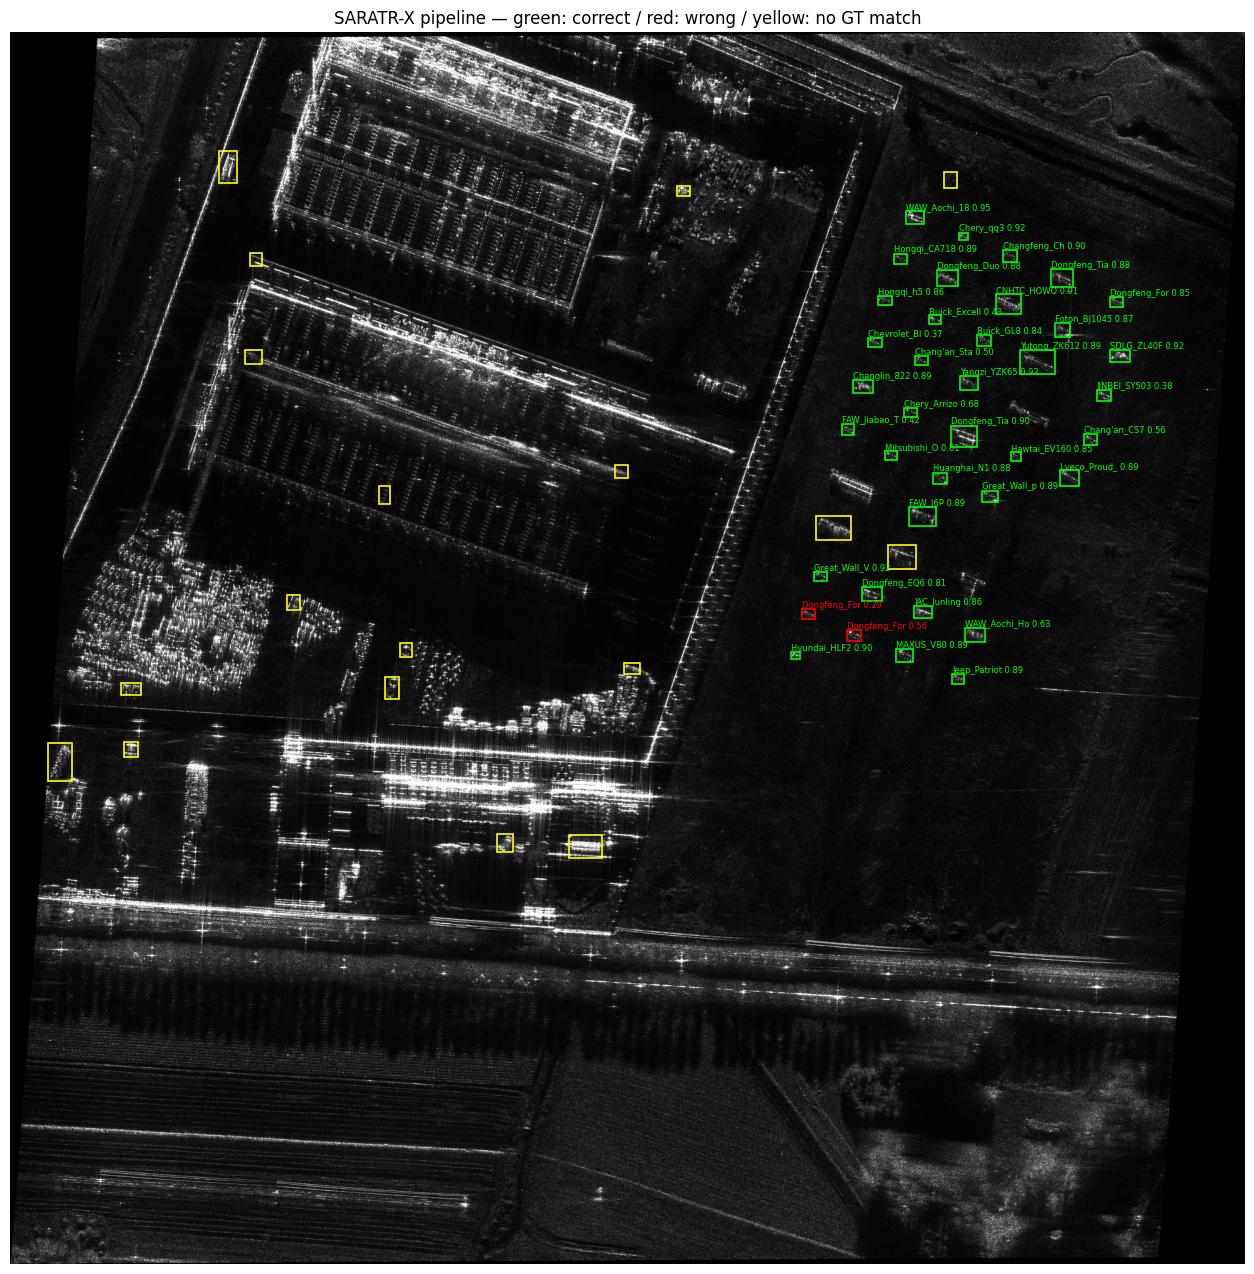

In [ ]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----- 정답 로드 -----
ann_path = SCENE.replace("/Result/", "/Annotation/").replace(".tif", ".xml")
root = ET.parse(ann_path).getroot()
gt = []
for obj in root.findall("object"):
    bb = obj.find("bndbox")
    box = [float(bb.find(t).text) for t in ["xmin", "ymin", "xmax", "ymax"]]
    gt.append((box, obj.find("type").text))

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

# ----- 3단계 채점 -----
n_det, n_cls = 0, 0
for g_box, g_type in gt:
    cands = [(iou(g_box, d["box"]), d) for d in detections if iou(g_box, d["box"]) >= 0.3]
    if not cands:
        continue
    n_det += 1
    _, best = max(cands, key=lambda c: c[0])
    if best["type"] == g_type:
        n_cls += 1

N = len(gt)
print(f"정답 표적: {N}대")
print(f"1) 탐지 recall:            {n_det}/{N} = {n_det/N*100:.1f}%   (ResNet18 버전: 95.0%)")
print(f"2) End-to-End 정확도:      {n_cls}/{N} = {n_cls/N*100:.1f}%   (ResNet18 버전: 70.0%)")
print(f"3) 분류 정확도(탐지 성공분): {n_cls}/{max(n_det,1)} = {n_cls/max(n_det,1)*100:.1f}%   (ResNet18 버전: 73.7%)")

# ----- 정답 대조 시각화 -----
fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(scene_rgb[:, :, 0], cmap="gray")
for d in detections:
    cands = [(iou(g_box, d["box"]), g_type) for g_box, g_type in gt if iou(g_box, d["box"]) >= 0.3]
    if not cands:
        color = "yellow"
    else:
        _, g_type = max(cands, key=lambda c: c[0])
        color = "lime" if d["type"] == g_type else "red"
    x1, y1, x2, y2 = d["box"]
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color=color, lw=1.2))
    if color != "yellow":
        ax.text(x1, y1 - 4, f'{d["type"][:12]} {d["cls_conf"]:.2f}', color=color, fontsize=6)
ax.set_title(f"SARATR-X pipeline — green: correct / red: wrong / yellow: no GT match")
ax.axis("off"); plt.show()

## 결과 기록 가이드

비교표에 한 행 추가 (보고서/노션용):

| 분류기 | 단독 acc | 파이프라인 acc | 장면 E2E | 장면 분류 |
|---|---|---|---|---|
| ResNet18 | 80.49% | 79.01% | 70.0% | 73.7% |
| SARATR-X | 89.30% | (파트 A 결과) | (파트 B 결과) | (파트 B 결과) |

확인 포인트:
- 탐지 recall은 두 버전이 같아야 정상 (탐지기 동일) — 다르면 설정 차이 의심
- 장면 분류 정확도 상승분 ≈ 단독 정확도 상승분(+8.8%p)과 비슷하면 일관성 있는 결과
- 빨간 박스(오답)가 ResNet18 그림과 어떻게 달라졌는지 비교하면 좋은 분석 거리